# MRNet — Role 5 Evaluation Runner

This notebook allows us to run the evaluation pipeline and visualise the outputs, all from one notebook.

This notebook **calls our `evaluation.py` script** with the same command-line arguments we would 
type in a terminal, afteer that it loads the MRNet files and then it writes (`results_*.json`, `significance_*.json`,
`master_table.csv`, the curve PNGs, and `*_triage.json`) and before rendering them.

**Before running:**
1. Save the latest `evaluation.py` into the `src/` folder (next to `modules/`).
2. Edit the four paths in section 1 so they point at the project.
3. `ipywidgets` is optional — if it isn't installed, just edit the `CONFIG` dict in section 3.
   (`pip install ipywidgets` to get the dropdown UI.)


## 1. Environment & paths

In [ ]:
import  sys, json, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image, Markdown
from pathlib import Path
%matplotlib inline

SRC_DIR    = Path.cwd() / "src"          # folder containing evaluation.py AND modules/
DATA_DIR   = SRC_DIR / "data"      # folder containing mrnet/ and mrnet_cropped/
CKPT_DIR   = SRC_DIR / "checkpoints"  # folder of trained model checkpoints
OUTPUT_DIR = SRC_DIR / "results"      # where evaluation.py writes its outputs
EVAL_SCRIPT = SRC_DIR / "cians_evaluation2.py"


OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

print("Path check:")
for p, name in [(EVAL_SCRIPT, "eval script"), (DATA_DIR, "data dir"),
                (CKPT_DIR, "checkpoint dir"), (OUTPUT_DIR, "output dir")]:
    print(f"  {'OK     ' if p.exists() else 'MISSING'}  {name:<16} {p}")


Path check:
  MISSING  evaluation.py  c:\Users\user\Documents\Med_imaging_project\code\src\src\evaluation.py
  MISSING  data dir       c:\Users\user\Documents\Med_imaging_project\code\src\src\data
  MISSING  checkpoint dir c:\Users\user\Documents\Med_imaging_project\code\src\checkpoints
  OK       output dir     c:\Users\user\Documents\Med_imaging_project\code\src\results


## 2. Choose what to run

The **Run mode** dropdown maps to the three commands:


* One condition — fixed 0.5 threshold -> `python evaluation.py --condition acl` 
* One condition — tuned threshold -> `python evaluation.py --condition acl --tune_threshold` 
* All conditions — tuned threshold -> `python evaluation.py --condition all --tune_threshold` 



In [ ]:
try:
    import ipywidgets as widgets
    HAVE_WIDGETS = True
except ImportError:
    HAVE_WIDGETS = False

if HAVE_WIDGETS:
    style = {'description_width': '130px'}
    preset = widgets.Dropdown(
        options=[
            ('One condition - fixed 0.5 threshold', 'single_fixed'),
            ('One condition - tuned threshold (Youden J on validation)', 'single_tuned'),
            ('All conditions - tuned threshold (master table)', 'all_tuned'),
        ],
        value='single_fixed', description='Run mode:', style=style,
        layout=widgets.Layout(width='560px'))
    condition = widgets.Dropdown(options=['acl', 'meniscus', 'abnormal'], value='acl',
                                 description='Condition:', style=style)
    architectures = widgets.SelectMultiple(options=['baseline', 'comparative'], value=('baseline',),
                                           description='Architectures:', style=style)
    data_modes = widgets.SelectMultiple(options=['uncropped', 'cropped'], value=('uncropped', 'cropped'),
                                        description='Data modes:', style=style)
    n_bootstraps = widgets.IntText(value=1000, description='Bootstraps:', style=style)
    seed = widgets.IntText(value=42, description='Seed:', style=style)

    def _toggle(*_):
        condition.disabled = (preset.value == 'all_tuned')
    preset.observe(_toggle, 'value'); _toggle()

    display(widgets.VBox([preset, condition, architectures, data_modes,
                          widgets.HBox([n_bootstraps, seed])]))
else:
    print("ipywidgets not installed - edit the CONFIG dict in the next cell to choose your run.")


## 3. Run the evaluation

In [ ]:
# Manual fallback used only when ipywidgets is NOT installed (edit as needed):
CONFIG = dict(
    preset='single_fixed',          # 'single_fixed' | 'single_tuned' | 'all_tuned'
    condition='acl',                # used by the single-condition presets
    architectures=('baseline',),    # ('baseline',) or ('baseline','comparative')
    data_modes=('uncropped', 'cropped'),
    n_bootstraps=1000,
    seed=42,
)

def get_config():
    if HAVE_WIDGETS:
        return dict(preset=preset.value, condition=condition.value,
                    architectures=tuple(architectures.value) or ('baseline',),
                    data_modes=tuple(data_modes.value) or ('uncropped',),
                    n_bootstraps=int(n_bootstraps.value), seed=int(seed.value))
    return CONFIG

cfg = get_config()

# Map the chosen preset to (condition, tune_threshold)
if cfg['preset'] == 'single_fixed':
    cond, tune = cfg['condition'], False
elif cfg['preset'] == 'single_tuned':
    cond, tune = cfg['condition'], True
else:                                    # 'all_tuned'
    cond, tune = 'all', True

cmd = [sys.executable, EVAL_SCRIPT,
       '--condition', cond,
       '--architectures', *cfg['architectures'],
       '--data_modes', *cfg['data_modes'],
       '--data_dir', str(DATA_DIR),
       '--checkpoint_dir', str(CKPT_DIR),
       '--output_dir', str(OUTPUT_DIR),
       '--n_bootstraps', str(cfg['n_bootstraps']),
       '--seed', str(cfg['seed'])]
if tune:
    cmd.append('--tune_threshold')

print('Running command:')
print('  ' + ' '.join(cmd) + '\n' + '-' * 70)

# Stream the script's output live as it runs
proc = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
                        text=True, bufsize=1)
for line in proc.stdout:
    print(line, end='')
proc.wait()
print('-' * 70)
print('Finished with exit code', proc.returncode)

# Remember which conditions to visualise below
RUN_CONDITIONS = ['acl', 'meniscus', 'abnormal'] if cond == 'all' else [cond]


## 4. Metrics tables (per-plane, fused, 2x2 matrix, significance)

In [ ]:
def load_results(condition):
    path = OUTPUT_DIR / f'results_{condition}.json'
    if not path.exists():
        return None
    with open(path) as f:
        return json.load(f)

def _ci(triple):
    v, lo, hi = triple
    return f"{v:.3f} [{lo:.3f}, {hi:.3f}]"

def fused_table(res):
    rows = {}
    for mode_key, d in res['modes'].items():
        row = {m: _ci(d['fused'][m]) for m in ['auc', 'sensitivity', 'specificity', 'f1']}
        row['threshold'] = round(d.get('threshold', 0.5), 3)
        rows[mode_key] = row
    return pd.DataFrame(rows).T

def perplane_table(res):
    recs = []
    for mode_key, d in res['modes'].items():
        for plane, mets in d['per_plane'].items():
            rec = {'mode': mode_key, 'plane': plane}
            rec.update({m: _ci(mets[m]) for m in ['auc', 'sensitivity', 'specificity', 'f1']})
            recs.append(rec)
    return pd.DataFrame(recs).set_index(['mode', 'plane']) if recs else pd.DataFrame()

for c in RUN_CONDITIONS:
    res = load_results(c)
    if res is None:
        print(f"No results_{c}.json found (was this condition evaluated?)")
        continue

    display(Markdown(f"### {c.upper()} - fused metrics  (value [95% CI])"))
    display(fused_table(res))

    display(Markdown(f"### {c.upper()} - per-plane metrics"))
    display(perplane_table(res))

    cells = res['matrix_2x2']['cells_fused_auc']
    effects = res['matrix_2x2']['effects']
    display(Markdown(f"**2x2 fused AUC cells:** `{cells}`  \n**Effects:** `{effects}`"))

    sig_path = OUTPUT_DIR / f'significance_{c}.json'
    if sig_path.exists():
        with open(sig_path) as f:
            sig = json.load(f)
        display(Markdown(f"### {c.upper()} - paired AUC-difference tests"))
        display(pd.DataFrame(sig).T)


## 5. Master table (only populated by the 'All conditions' run)

In [ ]:
mt_csv = OUTPUT_DIR / 'master_table.csv'
if mt_csv.exists():
    master = pd.read_csv(mt_csv)
    display(master)
else:
    print("No master_table.csv yet - run the 'All conditions - tuned threshold' preset to create it.")


## 6. Fused AUC comparison chart

In [ ]:
labels, vals, lo_err, hi_err = [], [], [], []
for c in RUN_CONDITIONS:
    res = load_results(c)
    if not res:
        continue
    for mode_key, d in res['modes'].items():
        v, lo, hi = d['fused']['auc']
        labels.append(f"{c}\n{mode_key}")
        vals.append(v); lo_err.append(v - lo); hi_err.append(hi - v)

if vals:
    x = np.arange(len(vals))
    fig, ax = plt.subplots(figsize=(max(7, len(vals) * 1.2), 5))
    ax.bar(x, vals, yerr=[lo_err, hi_err], capsize=4, color='#4C72B0')
    ax.axhline(0.5, ls='--', color='grey', lw=1, label='chance')
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=0, fontsize=8)
    ax.set_ylabel('Fused AUC'); ax.set_ylim(max(0.0, min(vals) - 0.1), 1.0)
    ax.set_title('Fused AUC with 95% CI'); ax.legend(loc='lower right')
    plt.tight_layout(); plt.show()
else:
    print("No fused AUC values to plot yet.")


## 7. ROC / PR curves

In [ ]:
pngs = sorted(OUTPUT_DIR.glob('*.png'))
pngs = [p for p in pngs if any(p.name.startswith(c) for c in RUN_CONDITIONS)]

if pngs:
    for p in pngs:
        display(Markdown(f"**{p.name}**"))
        display(Image(filename=str(p)))
else:
    print("No curve PNGs found for the current run.")


## 8. Triage preview (the JSON handed to Role 6)

In [ ]:
for c in RUN_CONDITIONS:
    tp = OUTPUT_DIR / f'{c}_triage.json'
    if not tp.exists():
        continue
    with open(tp) as f:
        tj = json.load(f)
    display(Markdown(
        f"### {c.upper()} triage - {tj['architecture']} / {tj['data_mode']} "
        f"(threshold {tj.get('threshold', 0.5):.3f}) - top 10 by fused confidence"))
    rows = []
    for case in tj['cases'][:10]:
        row = {'patient_id': case['patient_id'], 'true_label': case['true_label'],
               'fused_prob': round(case['fused_prob'], 3) if case['fused_prob'] is not None else None}
        for plane, pr in case['plane_probs'].items():
            row[plane] = round(pr, 3)
        rows.append(row)
    display(pd.DataFrame(rows))


## DUMMY RUN 
### Run check

#### Generating Dummy Predictions

In [ ]:
# DUMMY DATA TEST 
#import numpy as np
#
#CONDITIONS = ['acl', 'meniscus', 'abnormal']
#PLANES     = ['axial', 'coronal', 'sagittal']
#PREVALENCE = {'acl': 0.233, 'meniscus': 0.402, 'abnormal': 0.604}
#N_PATIENTS = 119   # size of the valid set
#
#np.random.seed(42)
#dummy = {}
#for cond in CONDITIONS:
#    labels = (np.random.rand(N_PATIENTS) < PREVALENCE[cond]).astype(int)
#    dummy[cond] = {}
#    for plane in PLANES:
#        signal = labels * 0.5
#        noise  = np.random.randn(N_PATIENTS) * 0.35
#        probs  = np.clip(signal + noise + 0.1, 0, 1)
#        dummy[cond][plane] = {
#            'probs':  probs.tolist(),
#            'labels': labels.tolist(),
#            'pids':   list(range(1130, 1130 + N_PATIENTS))
#        }
#
#print("Dummy predictions generated.")
#print(f"  Patients per plane: {N_PATIENTS}")
#for cond in CONDITIONS:
#    pos = sum(dummy[cond]['axial']['labels'])
#    print(f"  {cond}: {pos}/{N_PATIENTS} positive ({pos/N_PATIENTS:.1%})")

Dummy predictions generated.
  Patients per plane: 119
  acl: 34/119 positive (28.6%)
  meniscus: 61/119 positive (51.3%)
  abnormal: 69/119 positive (58.0%)


### DUMMY DATASET 2 (ACL= easier, MENISCUS= harder)

In [ ]:
#DUMMY DATA TEST (correlated-noise version)
import numpy as np

CONDITIONS = ['acl', 'meniscus', 'abnormal']
PLANES     = ['axial', 'coronal', 'sagittal']
PREVALENCE = {'acl': 0.233, 'meniscus': 0.402, 'abnormal': 0.604}
SIGNAL     = {'acl': 0.60, 'meniscus': 0.40, 'abnormal': 0.55}   # nudged up to offset the smaller fusion gain
N_PATIENTS = 119

np.random.seed(42)
dummy = {}
for cond in CONDITIONS:
    labels = (np.random.rand(N_PATIENTS) < PREVALENCE[cond]).astype(int)
    shared = np.random.randn(N_PATIENTS) * 0.25         # per-patient error shared by ALL 3 planes
    dummy[cond] = {}
    for plane in PLANES:
        plane_noise = np.random.randn(N_PATIENTS) * 0.25    # independent per-plane error
        probs = np.clip(labels * SIGNAL[cond] + shared + plane_noise + 0.1, 0, 1)
        dummy[cond][plane] = {                          
            'probs':  probs.tolist(),
            'labels': labels.tolist(),
            'pids':   list(range(1130, 1130 + N_PATIENTS))
        }

print("Dummy predictions generated.")
print(f"  Patients per plane: {N_PATIENTS}")
for cond in CONDITIONS:
    pos = sum(dummy[cond]['axial']['labels'])
    print(f"  {cond}: {pos}/{N_PATIENTS} positive ({pos/N_PATIENTS:.1%})")

Dummy predictions generated.
  Patients per plane: 119
  acl: 34/119 positive (28.6%)
  meniscus: 47/119 positive (39.5%)
  abnormal: 76/119 positive (63.9%)


#### Running Metrics and Printing Table

In [9]:
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix, average_precision_score

def _point_metrics(labels, probs, threshold=0.5):
    auc  = roc_auc_score(labels, probs)
    preds = (np.array(probs) >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(labels, preds, labels=[0,1]).ravel()
    return dict(
        auc         = auc,
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0,
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0,
        f1          = f1_score(labels, preds, zero_division=0)
    )

def bootstrap_ci(labels, probs, n=500, seed=42):
    rng = np.random.default_rng(seed)
    labels, probs = np.array(labels), np.array(probs)
    stats = []
    for _ in range(n):
        idx = rng.integers(0, len(labels), len(labels))
        if len(np.unique(labels[idx])) < 2:
            continue
        stats.append(_point_metrics(labels[idx], probs[idx]))
    keys = list(stats[0].keys())
    return {k: (float(np.mean([s[k] for s in stats])),
                float(np.percentile([s[k] for s in stats], 2.5)),
                float(np.percentile([s[k] for s in stats], 97.5))) for k in keys}

def fuse_dummy(plane_data):
    pid_map = {}
    for plane, d in plane_data.items():
        for pid, prob, label in zip(d['pids'], d['probs'], d['labels']):
            pid_map.setdefault(pid, {'probs': [], 'label': label})['probs'].append(prob)
    complete = {pid: v for pid, v in pid_map.items() if len(v['probs']) == len(plane_data)}
    return ([np.mean(v['probs']) for v in complete.values()],
            [v['label']         for v in complete.values()])

print(f"{'Condition':<12} {'Plane':<10} {'AUC':>6}  {'95% CI':<18}  {'Sens':>6}  {'Spec':>6}  {'F1':>6}")
print("-" * 75)
for cond in CONDITIONS:
    for plane in PLANES:
        d = dummy[cond][plane]
        m = bootstrap_ci(d['labels'], d['probs'])
        ci = f"[{m['auc'][1]:.3f}, {m['auc'][2]:.3f}]"
        print(f"{cond:<12} {plane:<10} {m['auc'][0]:>6.3f}  {ci:<18}  "
              f"{m['sensitivity'][0]:>6.3f}  {m['specificity'][0]:>6.3f}  {m['f1'][0]:>6.3f}")
    fp, fl = fuse_dummy(dummy[cond])
    fm = bootstrap_ci(fl, fp)
    ci = f"[{fm['auc'][1]:.3f}, {fm['auc'][2]:.3f}]"
    print(f"{cond:<12} {'FUSED':<10} {fm['auc'][0]:>6.3f}  {ci:<18}  "
          f"{fm['sensitivity'][0]:>6.3f}  {fm['specificity'][0]:>6.3f}  {fm['f1'][0]:>6.3f}")
    print()

Condition    Plane         AUC  95% CI                Sens    Spec      F1
---------------------------------------------------------------------------
acl          axial       0.902  [0.837, 0.950]       0.794   0.846   0.727
acl          coronal     0.894  [0.830, 0.948]       0.790   0.809   0.695
acl          sagittal    0.892  [0.825, 0.945]       0.733   0.857   0.700
acl          FUSED       0.938  [0.894, 0.976]       0.822   0.904   0.796

meniscus     axial       0.836  [0.753, 0.906]       0.551   0.821   0.598
meniscus     coronal     0.814  [0.727, 0.890]       0.524   0.904   0.622
meniscus     sagittal    0.827  [0.739, 0.901]       0.575   0.917   0.671
meniscus     FUSED       0.873  [0.805, 0.930]       0.507   0.918   0.617

abnormal     axial       0.848  [0.770, 0.916]       0.656   0.858   0.754
abnormal     coronal     0.899  [0.834, 0.951]       0.677   0.952   0.793
abnormal     sagittal    0.883  [0.819, 0.940]       0.626   0.863   0.734
abnormal     FUSED    

#### Plotting Dummy ROC and PR Curves

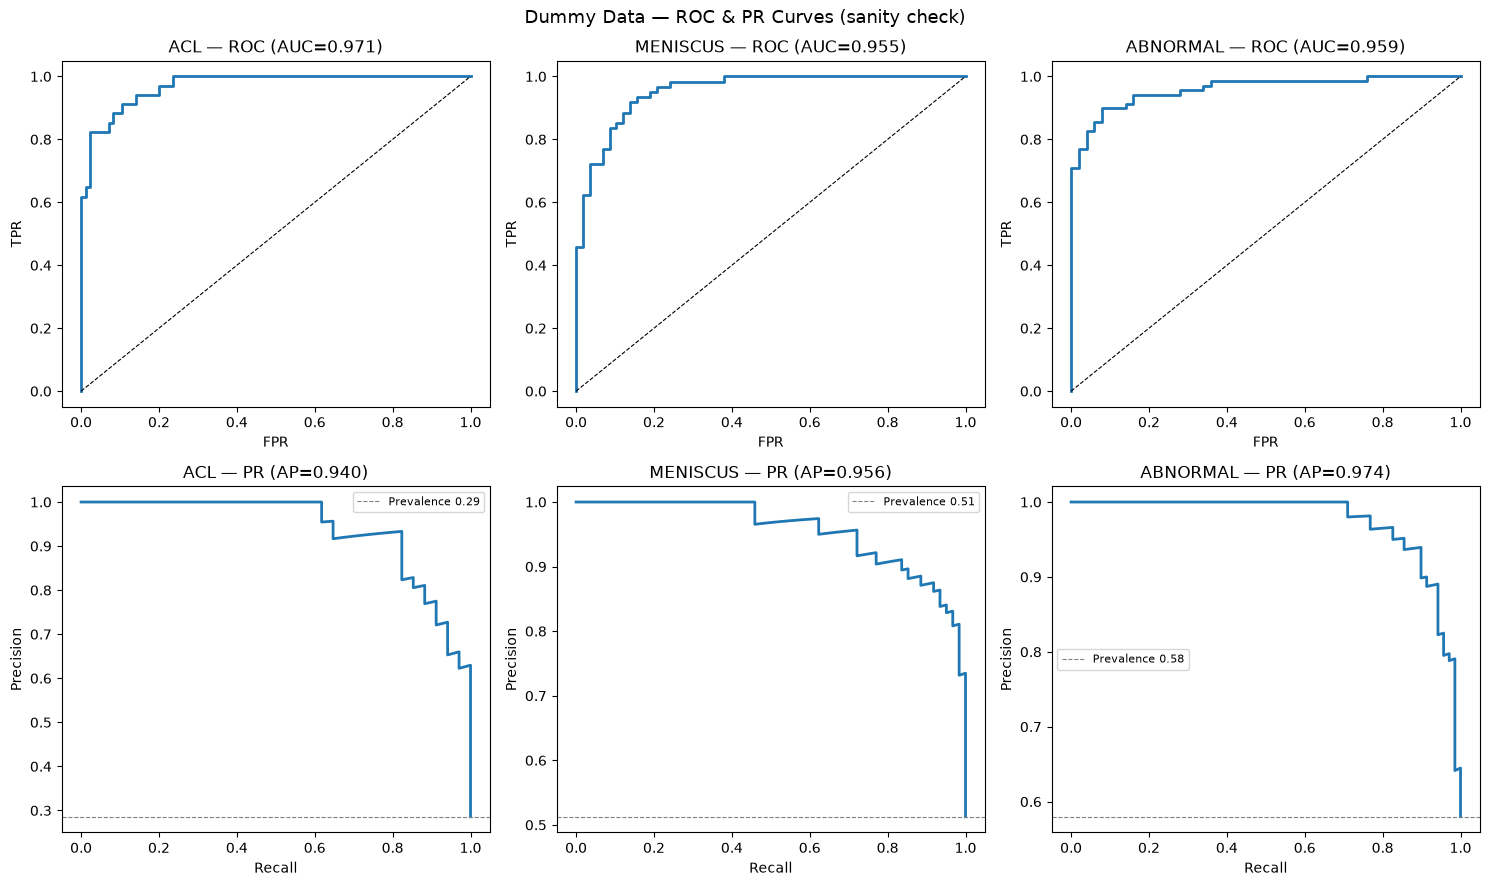

If curves look reasonable (ROC above diagonal, PR above prevalence line) — logic is correct.


In [4]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle("Dummy Data — ROC & PR Curves (sanity check)", fontsize=13)

for col, cond in enumerate(CONDITIONS):
    fp_vals, fl_vals = fuse_dummy(dummy[cond])
    prev = sum(fl_vals) / len(fl_vals)

    # ROC
    fpr, tpr, _ = roc_curve(fl_vals, fp_vals)
    auc = roc_auc_score(fl_vals, fp_vals)
    axes[0, col].plot(fpr, tpr, lw=2)
    axes[0, col].plot([0,1],[0,1],'k--', lw=0.8)
    axes[0, col].set_title(f"{cond.upper()} — ROC (AUC={auc:.3f})")
    axes[0, col].set_xlabel("FPR"); axes[0, col].set_ylabel("TPR")

    # PR
    prec, rec, _ = precision_recall_curve(fl_vals, fp_vals)
    ap = average_precision_score(fl_vals, fp_vals)
    axes[1, col].plot(rec, prec, lw=2)
    axes[1, col].axhline(prev, color='gray', linestyle='--', lw=0.8, label=f'Prevalence {prev:.2f}')
    axes[1, col].set_title(f"{cond.upper()} — PR (AP={ap:.3f})")
    axes[1, col].set_xlabel("Recall"); axes[1, col].set_ylabel("Precision")
    axes[1, col].legend(fontsize=8)

plt.tight_layout()
plt.show()
print("If curves look reasonable (ROC above diagonal, PR above prevalence line) — logic is correct.")